# 3. Multi-horizon evaluation

After selecting dynamic per-variable multiscale DLinear at a 96-step horizon, we keep that architecture fixed and test whether it generalizes to the four forecast horizons used in the paper: 96, 192, 336, and 720 steps.

This is a robustness experiment, not another model-selection stage.

## 1. Setup

All training is launched from this notebook. Completed runs are saved after every model so an interrupted experiment can continue without repeating finished work.

In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from ts_project.baselines import seasonal_naive_forecast
from ts_project.data import prepare_weather, build_weather_window_datasets
from ts_project.models import (
    DLinear,
    DynamicPerVariableMultiScaleDLinear,
    initialize_projections_from_dlinear,
)
from ts_project.training import seed_everything, train_forecaster

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "weather.csv"
RESULT_ROOT = PROJECT_ROOT / "results" / "dlinear" / "weather"
RUNS_PATH = RESULT_ROOT / "multihorizon_by_seed.csv"

INPUT_LENGTH = 336
HORIZONS = [96, 192, 336, 720]
SEEDS = [2021, 2022, 2023]
BATCH_SIZE = 16
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("Results file:", RUNS_PATH)

Device: cuda
Results file: d:\Projects\time-series-analysis-final-project\results\dlinear\weather\multihorizon_by_seed.csv


## 2. Experimental protocol

- Dataset, chronological split, and train-only scaling are unchanged.
- The input length remains 336 observations for every experiment.
- Only the prediction length changes.
- We compare the daily seasonal-naive baseline, reconstructed DLinear, and the already-selected dynamic multiscale model.
- DLinear and the dynamic model use the same three paired seeds, optimizer, loss, early stopping rule, and metrics.
- Seed 2021 matches the official implementation; seeds 2022 and 2023 are our robustness repetitions.
- We do not tune the architecture separately for the new horizons.

In [2]:
weather = prepare_weather(DATA_PATH)

design = pd.DataFrame(
    {
        "horizon": HORIZONS,
        "forecast steps": HORIZONS,
        "forecast hours": [h / 6 for h in HORIZONS],
        "input steps": INPUT_LENGTH,
        "input hours": INPUT_LENGTH / 6,
    }
)
design

,horizon,forecast steps,forecast hours,input steps,input hours
0,96,96,16.0,336,56.0
1,192,192,32.0,336,56.0
2,336,336,56.0,336,56.0
3,720,720,120.0,336,56.0


Weather is sampled every 10 minutes, so the longest horizon predicts five days at once from the previous 56 hours.

## 3. Evaluation and model helpers

The following functions keep the experiment compact. Test data is only evaluated after training has restored the checkpoint with the best validation MSE.

In [3]:
def make_loaders(horizon):
    datasets = build_weather_window_datasets(
        weather,
        input_length=INPUT_LENGTH,
        prediction_length=horizon,
    )
    return {
        "train": DataLoader(datasets["train"], batch_size=BATCH_SIZE, shuffle=True, drop_last=True),
        "validation": DataLoader(datasets["validation"], batch_size=BATCH_SIZE, shuffle=True, drop_last=True),
        "test": DataLoader(datasets["test"], batch_size=BATCH_SIZE, shuffle=False),
    }


@torch.inference_mode()
def evaluate_model(model, loader):
    model.eval()
    squared_sum = absolute_sum = 0.0
    count = 0
    for inputs, targets in loader:
        predictions = model(inputs.to(DEVICE)).cpu()
        errors = predictions - targets
        squared_sum += errors.square().sum().item()
        absolute_sum += errors.abs().sum().item()
        count += errors.numel()
    mse = squared_sum / count
    return {"mse": mse, "mae": absolute_sum / count, "rmse": mse**0.5}


@torch.inference_mode()
def evaluate_seasonal_naive(loader, horizon):
    squared_sum = absolute_sum = 0.0
    count = 0
    for inputs, targets in loader:
        predictions = seasonal_naive_forecast(inputs, horizon, season_length=144)
        errors = predictions - targets
        squared_sum += errors.square().sum().item()
        absolute_sum += errors.abs().sum().item()
        count += errors.numel()
    mse = squared_sum / count
    return {"mse": mse, "mae": absolute_sum / count, "rmse": mse**0.5}

In [4]:
def build_model(model_name, horizon, seed):
    seed_everything(seed)
    original = DLinear(
        input_length=INPUT_LENGTH,
        prediction_length=horizon,
        channels=len(weather.channel_names),
        moving_average=25,
        individual=False,
    )
    if model_name == "DLinear":
        return original

    seed_everything(seed)
    improved = DynamicPerVariableMultiScaleDLinear(
        input_length=INPUT_LENGTH,
        prediction_length=horizon,
        channels=len(weather.channel_names),
        kernel_sizes=(25, 73, 145),
        hidden_dimension=8,
    )
    initialize_projections_from_dlinear(improved, original)
    return improved


def run_trained_model(model_name, horizon, seed, loaders):
    model = build_model(model_name, horizon, seed)
    seed_everything(seed)
    started = time.perf_counter()
    training = train_forecaster(
        model,
        loaders["train"],
        loaders["validation"],
        device=DEVICE,
        learning_rate=1e-4,
        max_epochs=10,
        patience=3,
        verbose=True,
    )
    validation = evaluate_model(model, loaders["validation"])
    test = evaluate_model(model, loaders["test"])
    return {
        "horizon": horizon,
        "seed": str(seed),
        "model": model_name,
        "validation_mse": validation["mse"],
        "validation_mae": validation["mae"],
        "test_mse": test["mse"],
        "test_mae": test["mae"],
        "test_rmse": test["rmse"],
        "best_epoch": training.best_epoch,
        "parameters": sum(parameter.numel() for parameter in model.parameters()),
        "runtime_seconds": time.perf_counter() - started,
    }

## 4. Run the experiments

Running the next cell starts the full experiment. It may take roughly 30 to 90 minutes on the project GPU. Results are saved after each trained model. If execution stops, rerun the cell and completed model-seed-horizon combinations will be skipped.

In [5]:
RESULT_ROOT.mkdir(parents=True, exist_ok=True)
if RUNS_PATH.exists():
    records = pd.read_csv(RUNS_PATH).to_dict("records")
else:
    records = []

completed = {
    (int(row["horizon"]), str(row["model"]), str(row["seed"]))
    for row in records
}

for horizon in HORIZONS:
    print(f"\n===== Horizon {horizon} =====")
    loaders = make_loaders(horizon)

    baseline_key = (horizon, "Seasonal naive", "baseline")
    if baseline_key not in completed:
        baseline = evaluate_seasonal_naive(loaders["test"], horizon)
        records.append(
            {
                "horizon": horizon,
                "seed": "baseline",
                "model": "Seasonal naive",
                "validation_mse": np.nan,
                "validation_mae": np.nan,
                "test_mse": baseline["mse"],
                "test_mae": baseline["mae"],
                "test_rmse": baseline["rmse"],
                "best_epoch": np.nan,
                "parameters": 0,
                "runtime_seconds": 0.0,
            }
        )
        completed.add(baseline_key)

    for model_name in ("DLinear", "Dynamic multiscale V2A"):
        for seed in SEEDS:
            key = (horizon, model_name, str(seed))
            if key in completed:
                print("Already complete:", key)
                continue
            print(f"\n{model_name} | horizon {horizon} | seed {seed}")
            record = run_trained_model(model_name, horizon, seed, loaders)
            records.append(record)
            completed.add(key)
            pd.DataFrame(records).to_csv(RUNS_PATH, index=False)
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

runs = pd.DataFrame(records).sort_values(["horizon", "model", "seed"])
runs.to_csv(RUNS_PATH, index=False)
runs


===== Horizon 96 =====
Already complete: (96, 'DLinear', '2021')
Already complete: (96, 'DLinear', '2022')
Already complete: (96, 'DLinear', '2023')
Already complete: (96, 'Dynamic multiscale V2A', '2021')
Already complete: (96, 'Dynamic multiscale V2A', '2022')
Already complete: (96, 'Dynamic multiscale V2A', '2023')

===== Horizon 192 =====
Already complete: (192, 'DLinear', '2021')
Already complete: (192, 'DLinear', '2022')
Already complete: (192, 'DLinear', '2023')
Already complete: (192, 'Dynamic multiscale V2A', '2021')
Already complete: (192, 'Dynamic multiscale V2A', '2022')
Already complete: (192, 'Dynamic multiscale V2A', '2023')

===== Horizon 336 =====
Already complete: (336, 'DLinear', '2021')
Already complete: (336, 'DLinear', '2022')
Already complete: (336, 'DLinear', '2023')
Already complete: (336, 'Dynamic multiscale V2A', '2021')
Already complete: (336, 'Dynamic multiscale V2A', '2022')
Already complete: (336, 'Dynamic multiscale V2A', '2023')

===== Horizon 720 ====

,horizon,seed,model,validation_mse,validation_mae,test_mse,test_mae,test_rmse,best_epoch,parameters,runtime_seconds
0,96,2021,DLinear,0.426606,0.305006,0.174205,0.233328,0.417379,6.0,64704,95.605724
1,96,2022,DLinear,0.424415,0.305381,0.175208,0.236754,0.418579,5.0,64704,97.650746
2,96,2023,DLinear,0.426556,0.305405,0.174499,0.234509,0.417730,6.0,64704,97.116504
3,96,2021,Dynamic multiscale V2A,0.390399,0.289043,0.164952,0.223527,0.406143,6.0,64834,139.241739
4,96,2022,Dynamic multiscale V2A,0.388505,0.289105,0.165861,0.226255,0.407261,5.0,64834,138.744923
5,96,2023,Dynamic multiscale V2A,0.388321,0.288296,0.165394,0.224983,0.406687,9.0,64834,168.562222
6,96,baseline,Seasonal naive,NaN,NaN,0.316707,0.287956,0.562767,NaN,0,0.000000
7,192,2021,DLinear,0.483248,0.347022,0.215985,0.273504,0.464741,6.0,129408,92.570424
8,192,2022,DLinear,0.484010,0.347220,0.215693,0.272734,0.464428,9.0,129408,106.436651
9,192,2023,DLinear,0.484999,0.347357,0.215412,0.271858,0.464125,7.0,129408,103.792153


## 5. Summarize the repeated-seed results

The seasonal-naive baseline has no random seed. For the two learned models, we report the mean and sample standard deviation across the three seeds.

In [6]:
trained_runs = runs[runs["model"] != "Seasonal naive"].copy()
summary = (
    trained_runs.groupby(["horizon", "model"], as_index=False)
    .agg(
        test_mse_mean=("test_mse", "mean"),
        test_mse_std=("test_mse", "std"),
        test_mae_mean=("test_mae", "mean"),
        test_mae_std=("test_mae", "std"),
        runtime_minutes_mean=("runtime_seconds", lambda values: values.mean() / 60),
    )
)
summary

,horizon,model,test_mse_mean,test_mse_std,test_mae_mean,test_mae_std,runtime_minutes_mean
0,96,DLinear,0.174638,0.000516,0.234864,0.001741,1.613183
1,96,Dynamic multiscale V2A,0.165403,0.000455,0.224922,0.001365,2.480827
2,192,DLinear,0.215697,0.000286,0.272699,0.000823,1.682218
3,192,Dynamic multiscale V2A,0.208747,0.000723,0.265370,0.001753,2.726499
4,336,DLinear,0.262972,0.001418,0.314450,0.003131,1.103114
5,336,Dynamic multiscale V2A,0.257300,0.002141,0.308703,0.004215,1.676998
6,720,DLinear,0.324445,0.000689,0.362986,0.001255,1.241460
7,720,Dynamic multiscale V2A,0.319825,0.001091,0.357371,0.001507,2.191263


In [7]:
baseline = trained_runs[trained_runs["model"] == "DLinear"]
improved = trained_runs[trained_runs["model"] == "Dynamic multiscale V2A"]
paired = baseline.merge(improved, on=["horizon", "seed"], suffixes=("_dlinear", "_v2a"))
paired["mse_improvement_percent"] = 100 * (
    paired["test_mse_dlinear"] - paired["test_mse_v2a"]
) / paired["test_mse_dlinear"]
paired["mae_improvement_percent"] = 100 * (
    paired["test_mae_dlinear"] - paired["test_mae_v2a"]
) / paired["test_mae_dlinear"]

improvement_summary = paired.groupby("horizon", as_index=False).agg(
    mse_improvement_mean=("mse_improvement_percent", "mean"),
    mse_improvement_std=("mse_improvement_percent", "std"),
    mae_improvement_mean=("mae_improvement_percent", "mean"),
    mae_improvement_std=("mae_improvement_percent", "std"),
    mse_wins=("mse_improvement_percent", lambda values: int((values > 0).sum())),
    mae_wins=("mae_improvement_percent", lambda values: int((values > 0).sum())),
)
improvement_summary

,horizon,mse_improvement_mean,mse_improvement_std,mae_improvement_mean,mae_improvement_std,mse_wins,mae_wins
0,96,5.287950,0.062187,4.232425,0.188212,3,3
1,192,3.222173,0.210602,2.688156,0.365088,3,3
2,336,2.157681,0.349949,1.829194,0.561756,3,3
3,720,1.423828,0.158586,1.546998,0.143455,3,3


A positive improvement percentage means that dynamic per-variable multiscale DLinear has lower error than original DLinear. The paired comparison is important because both models use the same seed.

## 6. Visualize performance across horizons

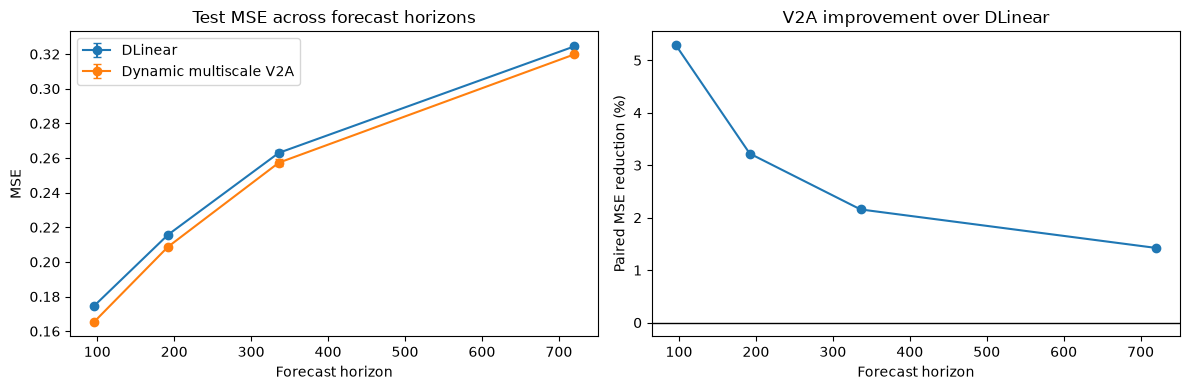

Saved: d:\Projects\time-series-analysis-final-project\results\dlinear\weather\figures\multihorizon_comparison.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for model_name, group in summary.groupby("model"):
    axes[0].errorbar(
        group["horizon"],
        group["test_mse_mean"],
        yerr=group["test_mse_std"],
        marker="o",
        capsize=3,
        label=model_name,
    )
axes[0].set(title="Test MSE across forecast horizons", xlabel="Forecast horizon", ylabel="MSE")
axes[0].legend()

axes[1].axhline(0, color="black", linewidth=1)
axes[1].plot(
    improvement_summary["horizon"],
    improvement_summary["mse_improvement_mean"],
    marker="o",
)
axes[1].set(
    title="V2A improvement over DLinear",
    xlabel="Forecast horizon",
    ylabel="Paired MSE reduction (%)",
)

plt.tight_layout()
figure_root = RESULT_ROOT / "figures"
figure_root.mkdir(parents=True, exist_ok=True)
figure_path = figure_root / "multihorizon_comparison.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", figure_path)

## 7. Interpretation

Dynamic per-variable multiscale DLinear outperforms its paired original DLinear run on both MSE and MAE for every seed at every horizon. That gives 12 out of 12 paired model wins on both metrics.

The mean paired MSE reductions are 5.29%, 3.22%, 2.16%, and 1.42% at horizons 96, 192, 336, and 720. The corresponding MAE reductions are 4.23%, 2.69%, 1.83%, and 1.55%. The adaptive decomposition therefore generalizes across all four horizons, although its relative benefit becomes smaller as the forecast grows longer.

The result extends the main experiment without changing the selected architecture or evaluation protocol. It shows that the benefit persists as forecasting becomes more difficult, while the decreasing gain suggests that adaptive decomposition has less influence at longer horizons. This remains evidence on one dataset and three seeds, not proof of improvement on every dataset. The dynamic model is parameter-efficient, but computing three moving averages makes training slower than original DLinear.